# Exercise 8: Coding and visualizing geostatistics (17 points)

The exercise this week will allow you to gain some experience with basic geostatistics by creating some Python functions for performing common statistical calculations and analyzing data from the [Smithsonian Institution's Global Volcanism Program](https://volcano.si.edu/).

One of the goals of this part of the course is to develop your quantitative geoscience skills, including learning how to convert mathematical equations to Python code. Doing this allows you to explore how various equations work and produce useful data plots or predictions, something increasingly done by geoscience professionals.

You'll use functions to calculate some statistics related to Holocene volcanoes from the [Smithsonian Institution's Global Volcanism Program](https://volcano.si.edu/).

### Scores for this problem

**Your score on this problem will be based on following criteria:**

- Properly converting the Gaussian formula to a Python function and saving them in the Python script file `gdam_functions.py`
 - **Note**:  ~~You should not use existing Python, Pandas or NumPy functions in the functions you create, other than perhaps a function for calculating the square root~~
- Including comments that explain what most lines in the code do
- Uploading your notebook and script file to your GitHub repository for this week's exercise

## Problem 1: Analyzing volcano data (8 points)

In this problem we'll utilize the functions generated in Problem 1 to calculate some statistics related to Holocene volcanoes from the [Smithsonian Institution's Global Volcanism Program](https://volcano.si.edu/).

### Scores for this problem

**Your score on this problem will be based on following criteria:**

- Reading and processing the [data file](data/GVP_Volcano_List_Holocene.csv)
- Cleaning the raw data as instructed
- Creating a new DataFrame of regional volcano statistics
- Including comments that explain what most lines in the code do
- Answering a couple questions at the end of the problem
- Uploading your notebook to your GitHub repository for this week's exercise

### Part 1: Reading the data file (1.5 points)

The first step in this exercise is to read in the [data file](data/GVP_Volcano_List_Holocene.csv) we're using. 

- For this, you should use the pandas `read_csv()` funtion to read in the data file [data/GVP_Volcano_List_Holocene.csv](data/GVP_Volcano_List_Holocene.csv) to the variable `data`
    - Use the semicolon character `;` as the separator between columns
    - Skip the first row

In [1]:
import pandas as pd

data = pd.read_csv("GVP_Volcano_List_Holocene.csv",skiprows=[0], sep = ";")

In [2]:
# This test print should print the head and the column names
print(data.head(1))
print(data.columns)


   Volcano Number               Volcano Name  Country Primary Volcano Type  \
0          210010  West Eifel Volcanic Field  Germany              Maar(s)   

  Activity Evidence Last Known Eruption                          Region  \
0    Eruption Dated            8300 BCE  Mediterranean and Western Asia   

        Subregion  Latitude  Longitude  Elevation (m) Dominant Rock Type  \
0  Western Europe     50.17       6.85            600            Foidite   

                         Tectonic Setting  
0  Rift zone / Continental crust (>25 km)  
Index(['Volcano Number', 'Volcano Name', 'Country', 'Primary Volcano Type',
       'Activity Evidence', 'Last Known Eruption', 'Region', 'Subregion',
       'Latitude', 'Longitude', 'Elevation (m)', 'Dominant Rock Type',
       'Tectonic Setting'],
      dtype='object')


In [3]:
# This test print should print the first row of data
print(data.loc[0].values)


[np.int64(210010) 'West Eifel Volcanic Field' 'Germany' 'Maar(s)'
 'Eruption Dated' '8300 BCE' 'Mediterranean and Western Asia'
 'Western Europe' np.float64(50.17) np.float64(6.85) np.int64(600)
 'Foidite' 'Rift zone / Continental crust (>25 km)']


In [4]:
# This test print should print the number of rows of data
print(f"The DataFrame contains {len(data)} rows.")


The DataFrame contains 1426 rows.


### Part 2: Preparing the data (1 point)

Before moving to using our statistical functions, we need to clean up our data a bit.

- Create a subset of the `data` dataframe called `clean_data` that contains only volcanoes with elevations at and above sea level
- Drop rows from the `clean_data` DataFrame with NaNs in the 'Tectonic Setting' column

In [5]:
clean_data = pd.DataFrame(data[data['Elevation (m)'] >= 0])
clean_data = clean_data.dropna(subset=['Tectonic Setting'])

In [6]:
# This test print should print the head
print(clean_data.head(1))


   Volcano Number               Volcano Name  Country Primary Volcano Type  \
0          210010  West Eifel Volcanic Field  Germany              Maar(s)   

  Activity Evidence Last Known Eruption                          Region  \
0    Eruption Dated            8300 BCE  Mediterranean and Western Asia   

        Subregion  Latitude  Longitude  Elevation (m) Dominant Rock Type  \
0  Western Europe     50.17       6.85            600            Foidite   

                         Tectonic Setting  
0  Rift zone / Continental crust (>25 km)  


In [7]:
# This test print should print the last 5 tectonic settings
print(clean_data["Tectonic Setting"].tail(5))


1420    Subduction zone / Oceanic crust (< 15 km)
1421    Subduction zone / Oceanic crust (< 15 km)
1422    Subduction zone / Oceanic crust (< 15 km)
1424      Intraplate / Continental crust (>25 km)
1425      Intraplate / Continental crust (>25 km)
Name: Tectonic Setting, dtype: object


### Part 3: Global volcano statistics (1 point)

With our clean data, we can now calculate some global statistical values for Holocene volcanoes.

- Calculate the mean elevation of all volcanoes in the `clean_data` DataFrame as variable `global_mean`
- Calculate the standard deviation in the elevation of all the volcanoes in the `clean_data` DataFrame as variable `global_stddev`
- Calculate the standard error in the elevation of all the volcanoes in the `clean_data` DataFrame as variable `global_stderr`

**Note**: You will need to use the `.values` attribute with the elevation data to calculate the requested values using the functions you created in Problem 1.

In [8]:
import numpy as np

global_mean = np.round(clean_data["Elevation (m)"].mean())
global_stddev = np.round(clean_data["Elevation (m)"].std())
global_stderr = np.round(global_stddev/ np.sqrt(len(clean_data["Elevation (m)"])))

In [9]:
# This should print the global mean volcano elevation
print(f"My global average volcano elevation is {global_mean} meters.")
print("The expected value is approximately 1922 meters.")


My global average volcano elevation is 1922.0 meters.
The expected value is approximately 1922 meters.


In [10]:
# This should print the global standard deviation in volcano elevation
print(f"My global standard deviation in volcano elevation is {global_stddev} meters.")
print("The expected value is approximately 1406 meters.")


My global standard deviation in volcano elevation is 1406.0 meters.
The expected value is approximately 1406 meters.


In [11]:
# This should print the global standard deviation in volcano elevation
print(f"My global standard error in volcano elevation is {global_stderr} meters.")
print("The expected value is approximately 39 meters.")


My global standard error in volcano elevation is 39.0 meters.
The expected value is approximately 39 meters.


### Part 4: Compiling regional volcano statistics (2 points)

Using an approach similar to that in Part 3, we can now calculate some statistics on volcanoes in various geographic regions.

- Create a variable `regions` that contains the unique 'Region' values from the `clean_data` DataFrame
- Using a `for` loop, loop over each region and append its mean, standard deviation, and standard error in volcano elevation to the empty list variables `means`, `stddevs`, and `stderrs`
    - **Note**: In your `for` loop you should first extract a subset of data using `.loc` to select the elevation values for the region of interest
    - You will also want to convert your subset of elevations to an array of values using the `.values` attribute before using your functions

In [12]:
means = []
stddevs = []
stderrs = []

# Selects unique values in the column Region of the clean_data DataFrame
regions = clean_data["Region"].unique()

# Calculates the mean, standard deviation, and standard error per region
for region in regions:
    regional_elevations = clean_data.loc[clean_data["Region"] == region, "Elevation (m)"].values
    means.append(regional_elevations.mean().round())
    stddevs.append(regional_elevations.std().round())
    stderrs.append((regional_elevations.std() / np.sqrt(len(regional_elevations))).round())

In [13]:
# This should print the last value in the regions array
print(f"The last region is {regions[-1]}.")


The last region is Antarctica.


In [14]:
# This should print the last value in the means list
print(f"The last mean value is {means[-1]} meters.")


The last mean value is 1670.0 meters.


In [15]:
# This should print the last value in the stddevs list
print(f"The last stddev value is {stddevs[-1]} meters.")


The last stddev value is 1209.0 meters.


In [16]:
# This should print the last value in the stderrs list
print(f"The last stderr value is {stderrs[-1]} meters.")


The last stderr value is 217.0 meters.


### Part 5: Creating a regional DataFrame (1.5 points)

The last step in this problem is to combine our new lists into a new Pandas DataFrame.

- Create a new DataFrame called `region_data` using `regions` as the index and the `means`, `stddevs`, and `stderrs` lists as the column data
    - **Hint**: When creating a DataFrame, column data can be specified in a dictionary using the `data` keyword (e.g., `data = {'Column heading': column_values}`), where `'Column heading'` would be the name of the column, and `column_values` would be the data in that column
    - **Hint**: The `index` parameter can be used to indicate the values to be used for the index

In [17]:
# Creates columns in the region_data Data Frame with corresponding regions as index
region_data = {"Mean elevation":means, "Standard Deviation":stddevs, "Standard errors":stderrs}
region_data = pd.DataFrame(region_data, index = regions)

In [18]:
# This should print the last row in the region_data DataFrame
print(region_data.tail(1))


            Mean elevation  Standard Deviation  Standard errors
Antarctica          1670.0              1209.0            217.0


In [19]:
# This should print the shape of the DataFrame
print(f"DataFrame dimensions: {region_data.shape}")


DataFrame dimensions: (19, 3)


In [20]:
# This should print mean elevation for Alaska
print(f"Alaska mean volcano elevation: {region_data['Mean elevation'].loc['Alaska']} meters.")


Alaska mean volcano elevation: 1500.0 meters.


### Part 6: Questions for Problem 2 (1 point)

1. How much do the standard deviation values vary among the regions? What do these values tell you about the volcano elevations in different regions?
2. Do you observe a large difference between the standard deviation and standard error values? Is it clear why you should always indicate whether reported values are standard deviations or standard errors?

In [21]:
print(f"Min stddev: {region_data['Standard Deviation'].min()} in {region_data['Standard Deviation'].idxmin()}")
print(f"Max stddev: {region_data['Standard Deviation'].max()} in {region_data['Standard Deviation'].idxmax()}")

print(f"Min std error: {region_data['Standard errors'].min()} in {region_data['Standard Deviation'].idxmin()}")
print(f"Max std error: {region_data['Standard errors'].max()} in {region_data['Standard Deviation'].idxmax()}")

Min stddev: 262.0 in West Indies
Max stddev: 1776.0 in South America
Min std error: 68.0 in West Indies
Max std error: 578.0 in South America


1. The standard deviation varies substantially across regions, ranging from a minimum of 262.0 meters in the West Indies to a maximum of 1776.0 meters in South America. Regions with high standard deviation, such as South America, show very diverse volcano elevations. Meanwhile, regions with low standard deviation indicate a more uniform volcano elevations within their region.
2. There’s a clear difference between standard deviation and standard error values—for example, South America’s standard deviation is 1776.0, but its standard error is only 578.0. The standard deviation reflects how spread out the data is, while the standard error shows the uncertainty in the mean. 

## Problem 2: Visualizing uncertainty (9 points)

In this problem we will continue to develop our Python mathematical and plotting skills by visualizing the regional volcano data using bar plots and the *normal distribution*. The normal distribution is a mathematical function with a bell shape, also known as the *Gauss function* or *Gaussian*. This function is centered on the mean value of a given set of values, where its value is greatest, and its value decreases away from the mean in what is hopefully a familiar form.

### Scores for this problem

**Your score on this problem will be based on following criteria:**

- Creating bar plots of the regional volcano data
- Properly defining a function for calulating normal distributions
- Creating a new DataFrame of regional volcano elevation distributions
- Including comments that explain what most lines in the code do
- Answering a couple questions at the end of the problem
- Uploading your notebook to your GitHub repository for this week's exercise

### Part 1: A bar plot of our regional volcano data (*1.5 points*)

We'll start visualizing our volcano data by creating a bar plot of the mean elevations along with their standard deviations.

- Create a bar plot of the mean elevations in the `region_data` DataFrame, including the standard deviation in elevation as an error bar
    - The data for the error bars can be assigned using the `yerr` parameter in the `.plot()` function
    - We suggest you use a slightly larger figure size of 12 by 8 inches, which can be set using the `figsize` parameter in the `.plot()` function
- Include a title and label on the y-axis
- Also add a black, dashed line spanning the width of the plot and indicating the global mean volcano elevation
    - Check the hints for this week's exercise about how to add this line
- Be sure to show a plot legend
- Finally, add a figure caption in the Markdown cell below the Python cell for your plot that describes the plot as if it were in a scientific journal article

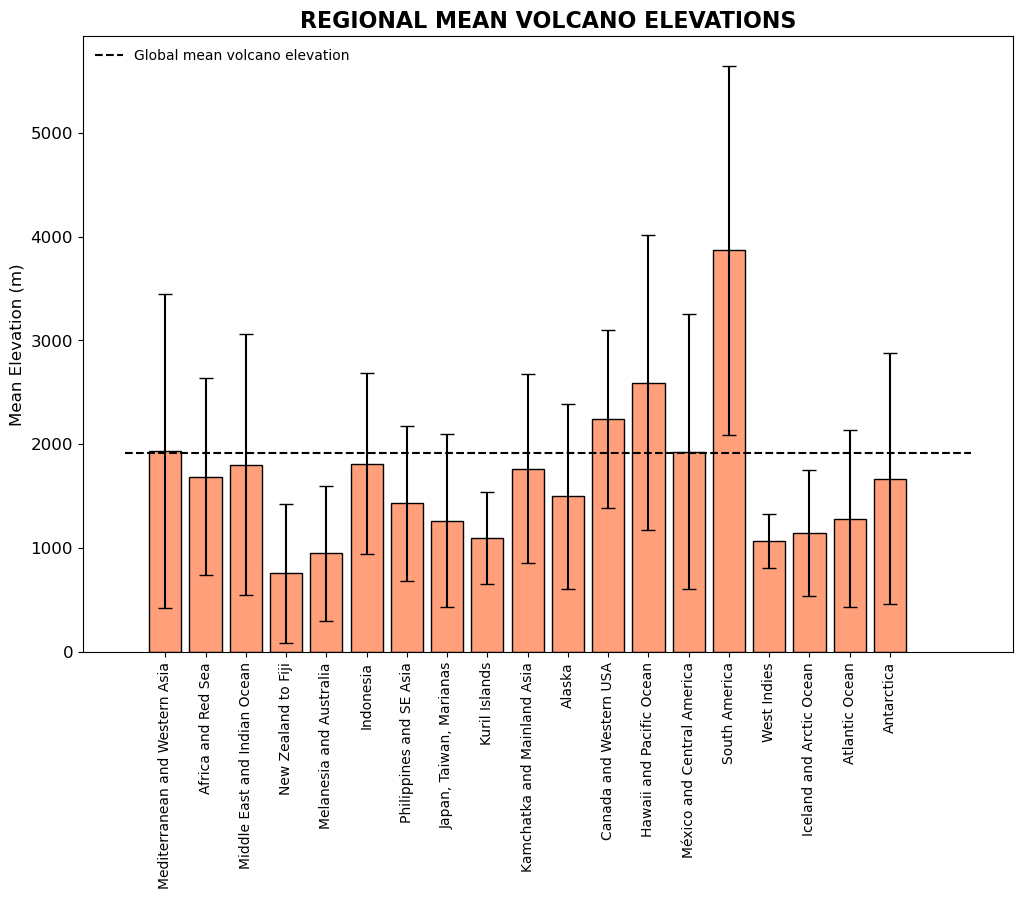

In [22]:
import matplotlib.pyplot as plt

# Create the figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

# Bar plot with error bars
ax.bar(
    regions,
    region_data["Mean elevation"],
    yerr=region_data["Standard Deviation"],
    capsize=5,  
    color='lightsalmon',
    edgecolor='black'
)

# Sets label and title
plt.title("REGIONAL MEAN VOLCANO ELEVATIONS", weight = "bold", fontsize = 16)
plt.ylabel("Mean Elevation (m)", fontsize = 12)

# For Design
plt.xticks(rotation=90)
plt.yticks(fontsize = 12)

# Horizontal dashed reference line of the global mean volcano elevation
plt.plot( 
    [-1, 20], 
    [1922, 1922], 
    color = "k", 
    linestyle='--', 
    linewidth=1.5,
    label = "Global mean volcano elevation"
)
# Creates the legend for the dashed line
plt.legend(loc='upper left', fontsize=10, frameon=False)

plt.show()

Figure 1. Mean elevations of volcanoes across different geographic regions, with error bars indicating the standard deviation of elevations within each region.

### Part 1: One more statistical function (2 points)

Your next task in this problem is to define the functions that will be needed to make plots of the normal distributions of the data from Problem 2.
We can start with the Gaussian function itself, which has a mathematical definition that is
\begin{equation}
  \Large
  G_{\bar{x}, \sigma_{x}}(x) = \frac{1}{\sigma_{x} \sqrt{2 \pi}} e^{-(x - \bar{x})^{2} / 2 \sigma_{x}^{2})}
\end{equation}

*Equation 4. The normal distribution*.

In this equation, $e$ is the exponential function, $x$ is the value for which the normal distribution is calculated (elevation in our case), $\bar{x}$ is the mean, and $\sigma_{x}$ is the standard deviation.
As we have already defined functions for the mean and standard deviation, you can use your earlier functions here.
**Note**: With the Gaussian function we are explicitly assuming here that the uncertainty is symmetric and follows a bell-shaped distribution about the mean.

For this part you should:

- Add NumPy to the list of modules to import at the start of the `gdam_functions.py` file in order to be able to use the exponential function and one for calculating the square root
- Define a new function called `gaussian()` in the `gdam_functions.py` file, which you can use to calculate the normal distribution.
    - **Note**: You will have more than one parameter when defining this function.
- Use your function in the cell below to calculate the Gaussian value for the specified input parameter values.

In [23]:
# Use your gaussian function below to calculate the value for a mean of 2.0, std dev of 1.0, and at x = 1.0
from gdam_functions import gaussian

gauss_mean = 2.0
gauss_stddev = 1.0
gauss_x = 1.0
test_gauss = gaussian(gauss_x, gauss_mean, gauss_stddev)

print(f'{test_gauss:.2f}')

0.24


In [24]:
# Import the new gaussian function along with the old ones
from gdam_functions import gaussian

# This test should also work
print(f"The Gaussian value for this test should be 0.3989. My Gaussian value is: {gaussian(1, 1, [1])[0]}.")

The Gaussian value for this test should be 0.3989. My Gaussian value is: 0.3989422804014327.


In [25]:
# This test should work
print(f"The Gaussian value for this test should be 0.1994. My Gaussian value is: {gaussian(2, 2, [2])[0]}.")


The Gaussian value for this test should be 0.1994. My Gaussian value is: 0.19947114020071635.


### Part 4: Calculating normal distributions for our elevation data (1 point)

Your next task now that we have the functions defined is to calculate the normal distributions for each of the regional volcano elevations from Problem 2. You can use the mean and standard deviation values calculated in the `region_data` DataFrame for this.

- Define a NumPy array called `elevations` that goes from 0 to 8000 meters in 1001 steps
- Create a new empty Pandas DataFrame called `gaussians` with `elevations` as the index
- Use a `for` loop to loop over each region in the `regions` array defined back in Problem 2
    - For each region, calculate the normal distribution of volcano elevations using the regional mean elevation and standard deviation in elevation over the range of elevations in the `elevations` array
    - Save each normal distribution in a new column named for the region
        - As you may recall, you can easily add a new column by assigning values to a new column name in the DataFrame. For example, `df['New column'] = elevations` would assign the values from the `elevations` array to a new column in the DataFrame `df` called `'New column'`

In [28]:
# Array of elevations
elevations = np.linspace(0, 8000, 1001)

# New DataFrame for normal distributions
gaussians = pd.DataFrame(index = elevations)

# Calculates the normal distribution per region 
for region in regions:
    mean =region_data.loc[region, "Mean elevation"]
    stddev = region_data.loc[region, "Standard Deviation"]
    gaussians[region] = gaussian(elevations, mean, stddev)

,Mediterranean and Western Asia,Africa and Red Sea,Middle East and Indian Ocean,New Zealand to Fiji,Melanesia and Australia,Indonesia,Philippines and SE Asia,"Japan, Taiwan, Marianas",Kuril Islands,Kamchatka and Mainland Asia,Alaska,Canada and Western USA,Hawaii and Pacific Ocean,México and Central America,South America,West Indies,Iceland and Arctic Ocean,Atlantic Ocean,Antarctica
0.0,1.160899e-04,8.570446e-05,1.125821e-04,3.134487e-04,2.089678e-04,5.163558e-05,8.512079e-05,1.506268e-04,4.058286e-05,6.662893e-05,1.085422e-04,1.494502e-05,5.270315e-05,1.041372e-04,0.000021,3.526144e-07,1.076884e-04,1.496580e-04,1.271057e-04
8.0,1.168806e-04,8.700320e-05,1.136223e-04,3.176947e-04,2.127960e-04,5.263811e-05,8.687790e-05,1.528362e-04,4.244232e-05,6.777468e-05,1.101909e-04,1.531574e-05,5.324982e-05,1.050565e-04,0.000021,3.993520e-07,1.104357e-04,1.517925e-04,1.282700e-04
16.0,1.176733e-04,8.831531e-05,1.146674e-04,3.219523e-04,2.166612e-04,5.365556e-05,8.866114e-05,1.550637e-04,4.437251e-05,6.893480e-05,1.118556e-04,1.569427e-05,5.380045e-05,1.059801e-04,0.000021,4.518631e-07,1.132332e-04,1.539438e-04,1.294392e-04
24.0,1.184681e-04,8.964082e-05,1.157174e-04,3.262205e-04,2.205627e-04,5.468802e-05,9.047064e-05,1.573091e-04,4.637535e-05,7.010935e-05,1.135363e-04,1.608076e-05,5.435505e-05,1.069080e-04,0.000022,5.108024e-07,1.160811e-04,1.561119e-04,1.306135e-04
32.0,1.192649e-04,9.097972e-05,1.167722e-04,3.304981e-04,2.245001e-04,5.573562e-05,9.230650e-05,1.595723e-04,4.845279e-05,7.129838e-05,1.152330e-04,1.647532e-05,5.491360e-05,1.078400e-04,0.000022,5.768914e-07,1.189798e-04,1.582965e-04,1.317926e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7968.0,8.963307e-08,1.205855e-13,1.750918e-09,4.319602e-29,1.478783e-29,5.633572e-15,1.420487e-20,4.247077e-18,6.422030e-56,3.392407e-14,1.614574e-15,8.572589e-14,2.119665e-07,9.181456e-09,0.000016,5.604377e-154,1.126003e-31,1.919613e-17,4.225546e-10
7976.0,8.775232e-08,1.140139e-13,1.696676e-09,3.798545e-29,1.292561e-29,5.277051e-15,1.293695e-20,3.931132e-18,4.853609e-56,3.194543e-14,1.512633e-15,8.051628e-14,2.074729e-07,8.931748e-09,0.000015,2.507782e-154,9.690461e-32,1.782944e-17,4.082285e-10
7984.0,8.590861e-08,1.077928e-13,1.644047e-09,3.339864e-29,1.129617e-29,4.942673e-15,1.178086e-20,3.638356e-18,3.667040e-56,3.007986e-14,1.417015e-15,7.561664e-14,2.030681e-07,8.688514e-09,0.000015,1.121108e-154,8.338211e-32,1.655858e-17,3.943707e-10
7992.0,8.410128e-08,1.019038e-13,1.592986e-09,2.936151e-29,9.870631e-30,4.629090e-15,1.072685e-20,3.367073e-18,2.769650e-56,2.832105e-14,1.327334e-15,7.100893e-14,1.987505e-07,8.451595e-09,0.000015,5.007261e-155,7.173398e-32,1.537695e-17,3.809667e-10


In [29]:
# This test print should work
print(f"The elevation at index 400 is {elevations[400]}. The expected value is 3200.0.")


The elevation at index 400 is 3200.0. The expected value is 3200.0.


In [30]:
# This should print the shape of the DataFrame
print(f"DataFrame dimensions: {gaussians.shape}")


DataFrame dimensions: (1001, 19)


### Part 5: Plotting our volcano data, version 2.0 (2 points)

Finally, we can plot our normal distributions.

- Create a plot of the data in the `gaussians` DataFrame using the Pandas `.plot()` function
    - Include a title and again we suggest a figure size of 12 by 8 inches
- Label the x- and y-axes
    - The y-axis label should be 'Probability'
- Set the range for the y-axis to go from 0.0 to 0.0016
- Finally, add a figure caption in the Markdown cell below the Python cell for your plot that describes the plot as if it were in a scientific journal article

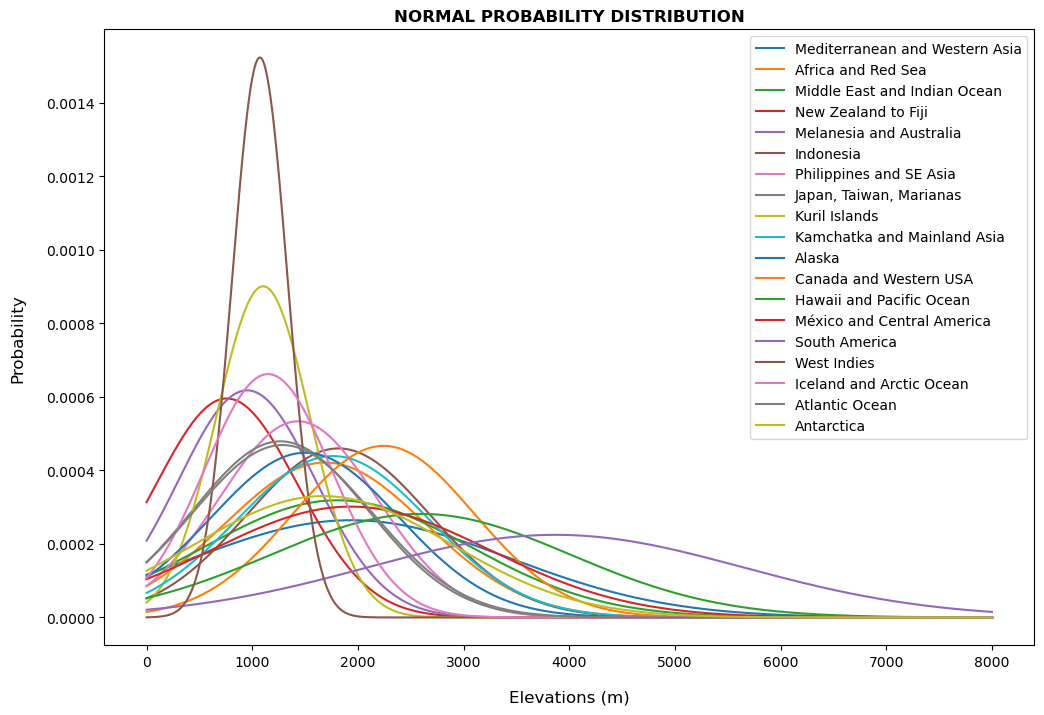

In [44]:
ax = gaussians.plot(figsize = [12,8])

ax.set_title("GAUSSIAN PROBABILITY DISTRIBUTION", fontweight='bold', fontsize=12)
ax.set_xlabel("Elevations (m)", fontsize=12, labelpad=15)
ax.set_ylabel("Probability", fontsize=12, labelpad=15)

plt.show()

Figure 2: Normal Probability Distribution of elevation data for distinct geographic regions.

### Part 6: Questions for Problem 3 (1 point)

1. How does the shape of the Gaussian distribution change for different values of the standard deviation?
2. Using this method of visualization, is it clear which regions have larger or smaller variations in average volcano elevation?

1. The standard deviation determines the spread of the Gaussian curve, indicating the degree to which values deviate from the mean. A lower standard deviation results in a taller and narrower curve, showing that most values are concentrated near the mean. Conversely, a higher standard deviation produces a wider and flatter curve, reflecting greater variability in the data.

2. This method of visualization makes it easier to assess the variability in elevation across regions. Regions with wider Gaussian curves exhibit greater variation in elevation, while narrower curves suggest more consistent elevation values around the mean.